# Exercise 1 — Linear Regression


## Part A: Understanding LR

Imagine we have data from a small restaurant.

For each table, we know:

- the total bill
- the tip left by the customer

We want to predict the tip from the bill using a straight line:

`predicted tip = weight × bill + bias`

Your task is to change `weight` and `bias` until the line fits the data as well as possible.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Sample restaurant data
# x = total bill in dollars
# y = tip in dollars

x = np.array([10, 12, 15, 18, 20, 22, 25, 28, 30, 35, 40, 45])

y = np.array([1.8, 2.0, 2.7, 3.0, 3.6, 3.5, 4.2, 4.8, 5.0, 5.8, 6.5, 7.0])

In [9]:
# You should change only these two numbers
weight = 0.153

bias = 0.314

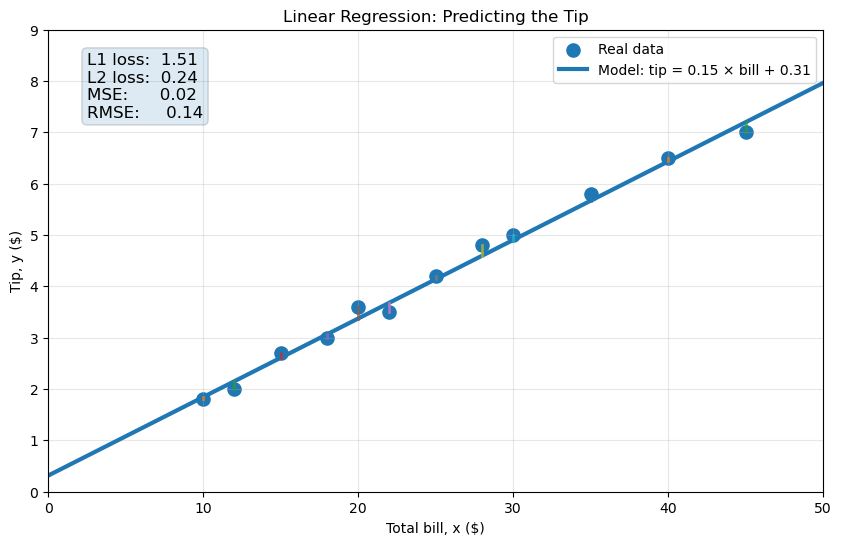

In [10]:
# Predictions
y_pred = weight * x + bias

# Residuals and losses
residuals = y - y_pred

l1 = np.sum(np.abs(residuals))
l2 = np.sum(residuals ** 2)
mse = np.mean(residuals ** 2)
rmse = np.sqrt(mse)


# Plot
plt.figure(figsize=(10, 6))

plt.scatter(x, y, s=90, label="Real data")

# Regression line
x_line = np.linspace(0, 50, 100)
y_line = weight * x_line + bias

plt.plot(
    x_line,
    y_line,
    linewidth=3,
    label=f"Model: tip = {weight:.2f} × bill + {bias:.2f}"
)

# Residual lines
for xi, yi, ypi in zip(x, y, y_pred):
    plt.plot([xi, xi], [yi, ypi], linewidth=2, alpha=0.7)

plt.title("Linear Regression: Predicting the Tip")
plt.xlabel("Total bill, x ($)")
plt.ylabel("Tip, y ($)")

plt.xlim(0, 50)
plt.ylim(0, 9)
plt.grid(True, alpha=0.3)
plt.legend()

loss_text = (
    f"L1 loss:  {l1:.2f}\n"
    f"L2 loss:  {l2:.2f}\n"
    f"MSE:      {mse:.2f}\n"
    f"RMSE:     {rmse:.2f}"
)

plt.text(
    0.05,
    0.95,
    loss_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15),
    fontsize=12
)

plt.show()

### Your task

Change the values of `weight` and `bias`, then rerun the cell.

Try to make the line fit the points as well as possible.

Questions:

1. What is the lowest MSE you can find?
2. Which values of `weight` and `bias` gave you that MSE?
3. What happens to the residual lines when the model improves?
4. What does the `weight` mean in this example?
5. What does the `bias` mean?

In [11]:
1) The lowest MSE value i can find is 0.02
2) Value of "weight": 0.153
   Value of "bias": 0.314
3) When the model improves the prediction line gets closer to the real point and becomes smaller -> improved
4) It means for every 1$ extra from the bill, then the tip increases by about 0.153$
5) It means "bias" is the starting point of the prediction

SyntaxError: unmatched ')' (2869231209.py, line 1)

In [8]:
# Compute the best linear regression solution automatically

best_weight, best_bias = np.polyfit(x, y, 1)

y_best = best_weight * x + best_bias
best_mse = np.mean((y - y_best) ** 2)
best_rmse = np.sqrt(best_mse)

print(f"Best weight: {best_weight:.3f}")
print(f"Best bias:   {best_bias:.3f}")
print(f"Best MSE:    {best_mse:.3f}")
print(f"Best RMSE:   {best_rmse:.3f}")

Best weight: 0.154
Best bias:   0.315
Best MSE:    0.019
Best RMSE:   0.139


## Part B: Use a real dataset

In the previous exercise, we used (unexisting) sample data.

Now choose one real dataset and repeat the same process:

1. Load the dataset.
2. Choose one numerical column as `x`.
3. Choose one numerical column as `y`.
4. Fit a line manually by changing `weight` and `bias`.
5. Compute the residuals, MSE, and RMSE.
6. Compare your manual line with the best line found by Python.

The model is always:

`y_pred = weight * x + bias`

### Option 1 — Student performance dataset from Hugging Face

This one is probably closest to your idea:

> Can we predict exam score from study hours?

The Hugging Face dataset `krishal07/student-performance` includes columns such as `StudyHours`, `TestScore_Math`, `TestScore_Reading`, `TestScore_Science`, `GPA`, and `AttendanceRate`.  

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset("krishal07/student-performance", split="train")

df = dataset.to_pandas()
df.head()

,Age,Grade,Gender,Race,SES_Quartile,ParentalEducation,SchoolType,Locale,TestScore_Math,TestScore_Reading,...,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
0,17,12,Female,White,3,HS,Public,Suburban,70.258235,79.665185,...,2.743879,0.906809,1.089243,1,1,0,0,0,2,2
1,18,12,Female,White,2,HS,Public,Suburban,67.876546,59.611505,...,2.587700,0.843739,0.879911,1,1,0,1,0,5,2
2,16,11,Female,White,2,HS,Public,City,62.070623,70.577443,...,2.426294,0.850923,1.003442,1,1,0,1,1,5,1
3,14,9,Female,White,4,Bachelors+,Public,Town,79.909312,82.924450,...,3.558240,0.946786,1.814810,1,1,0,1,0,4,2
4,16,11,Female,Two-or-more,4,SomeCollege,Public,Rural,90.562294,95.352336,...,3.896884,0.988036,1.157241,1,1,0,0,0,3,4


In [66]:
# Question:
# Can we predict math test score from study hours?

x = df["StudyHours"].to_numpy()
y = df["TestScore_Math"].to_numpy()

print("Number of students:", len(x))
print("First 5 study-hour values:", x[:5])
print("First 5 math scores:", y[:5])

Number of students: 8000774
First 5 study-hour values: [1.08924319 0.87991072 1.00344238 1.81481015 1.15724067]
First 5 math scores: [70.25823548 67.87654582 62.07062326 79.90931215 90.56229366]


#### Questions

1. Does more study time usually mean a higher test score?
2. Is the relationship perfectly linear?
3. Are there students with high study time but lower scores?
4. What other variables might help predict exam score?

### Option 2 — Bike rentals and weather

This is a good urban-mobility example:

> Can we predict bike rentals from temperature?

Use the UCI Bike Sharing Dataset. It contains bike rental counts together with weather and seasonal information. The official UCI page describes this as a bike-sharing dataset with hourly and daily rental counts plus weather/seasonal information.  

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip"
zip_path = "Bike-Sharing-Dataset.zip"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path) as z:
    with z.open("day.csv") as f:
        df = pd.read_csv(f)

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [68]:
# Question:
# Can we predict total daily bike rentals from temperature?

x = df["temp"].to_numpy()
y = df["cnt"].to_numpy()

print("Number of days:", len(x))
print("First 5 temperature values:", x[:5])
print("First 5 rental counts:", y[:5])

Number of days: 731
First 5 temperature values: [0.344167 0.363478 0.196364 0.2      0.226957]
First 5 rental counts: [ 985  801 1349 1562 1600]


#### Questions

1. Do warmer days usually have more bike rentals?
2. Is temperature enough to explain bike rentals?
3. Where are the residuals largest?
4. What other variables might help?

### Option 3 — Tips dataset

This is simple and easy to understand:

> Can we predict the tip from the total bill?

The `seaborn-data` repository provides sample datasets used in `seaborn` examples, including `tips.csv`.  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

df = pd.read_csv(url)
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
# Question:
# Can we predict the tip from the total bill?

x = df["total_bill"].to_numpy()
y = df["tip"].to_numpy()

print("Number of tables:", len(x))
print("First 5 bills:", x[:5])
print("First 5 tips:", y[:5])

Number of tables: 244
First 5 bills: [16.99 10.34 21.01 23.68 24.59]
First 5 tips: [1.01 1.66 3.5  3.31 3.61]


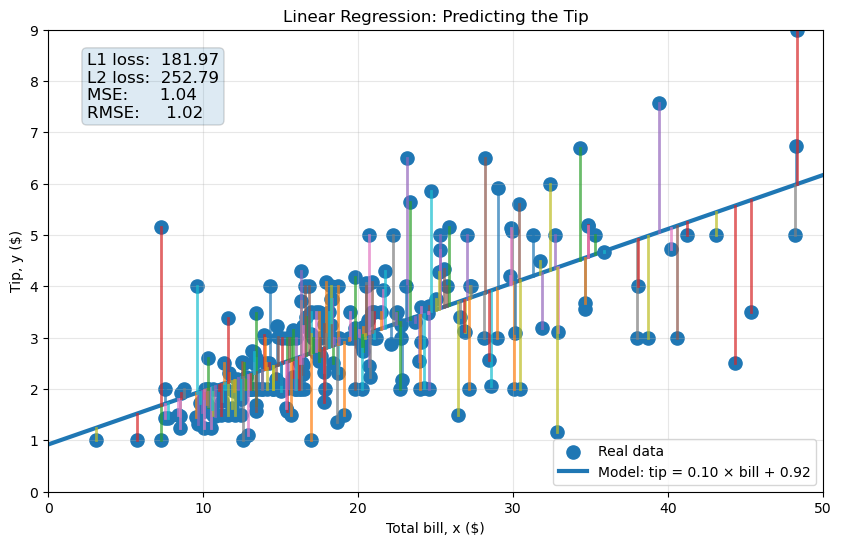

In [3]:
weight = 0.105

bias = 0.92

# Predictions
y_pred = weight * x + bias

# Residuals and losses
residuals = y - y_pred

l1 = np.sum(np.abs(residuals))
l2 = np.sum(residuals ** 2)
mse = np.mean(residuals ** 2)
rmse = np.sqrt(mse)


# Plot
plt.figure(figsize=(10, 6))

plt.scatter(x, y, s=90, label="Real data")

# Regression line
x_line = np.linspace(0, 50, 100)
y_line = weight * x_line + bias

plt.plot(
    x_line,
    y_line,
    linewidth=3,
    label=f"Model: tip = {weight:.2f} × bill + {bias:.2f}"
)

# Residual lines
for xi, yi, ypi in zip(x, y, y_pred):
    plt.plot([xi, xi], [yi, ypi], linewidth=2, alpha=0.7)

plt.title("Linear Regression: Predicting the Tip")
plt.xlabel("Total bill, x ($)")
plt.ylabel("Tip, y ($)")

plt.xlim(0, 50)
plt.ylim(0, 9)
plt.grid(True, alpha=0.3)
plt.legend()

loss_text = (
    f"L1 loss:  {l1:.2f}\n"
    f"L2 loss:  {l2:.2f}\n"
    f"MSE:      {mse:.2f}\n"
    f"RMSE:     {rmse:.2f}"
)

plt.text(
    0.05,
    0.95,
    loss_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15),
    fontsize=12
)

plt.show()

In [4]:
# Compute the best linear regression solution automatically

best_weight, best_bias = np.polyfit(x, y, 1)

y_best = best_weight * x + best_bias
best_mse = np.mean((y - y_best) ** 2)
best_rmse = np.sqrt(best_mse)

print(f"Best weight: {best_weight:.3f}")
print(f"Best bias:   {best_bias:.3f}")
print(f"Best MSE:    {best_mse:.3f}")
print(f"Best RMSE:   {best_rmse:.3f}")

Best weight: 0.105
Best bias:   0.920
Best MSE:    1.036
Best RMSE:   1.018


#### Questions

1. Does a larger bill usually mean a larger tip?
2. What does the weight mean in this example?
3. Can one line explain all tipping behavior?
4. What other variables might help?

In [ ]:
1) Yes. The data show that on the upward slope of the regression line, there is a positive correlation. As the bill increases, the tip
generally increases as well
2)The weight (0.105) represents the marginal increase in tip for every additional dollar spent on the bill. Effectively, it indicates 
a tipping rate of approximately 10.5%.
3)No one line cannot explain all behaviors. This is evident from the residuals.
4)The size - the number of people at the table might improve the accuracy for the dataset.

### Option 4 — Car fuel efficiency

This is useful because the relationship is negative:

> Can we predict fuel efficiency from car weight?

The `mpg.csv` dataset is also available in the `seaborn-data` repository.  

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)
df = df.dropna()

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [72]:
# Question:
# Can we predict miles per gallon from car weight?

x = df["weight"].to_numpy()
y = df["mpg"].to_numpy()

print("Number of cars:", len(x))
print("First 5 weights:", x[:5])
print("First 5 mpg values:", y[:5])

Number of cars: 392
First 5 weights: [3504 3693 3436 3433 3449]
First 5 mpg values: [18. 15. 18. 16. 17.]


#### Questions

1. Do heavier cars usually have lower fuel efficiency?
2. Is the relationship perfectly linear?
3. What other variables might help predict fuel efficiency?

### Option 5 — Find another dataset!

If you prefer, look for another dataset that interests you.

Good places to search:

- [Hugging Face Datasets](https://huggingface.co/datasets)
- [Kaggle Datasets](https://www.kaggle.com/datasets)
- [UCI Machine Learning Repository](https://archive.ics.uci.edu/datasets)
- [Seaborn example datasets](https://github.com/mwaskom/seaborn-data)

Your dataset should have at least two numerical columns.

Use [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) from [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) to train the model.

Choose:

- one numerical column as `x`
- one numerical column as `y`

Then ask a question like:

`Can we predict y from x?`

Examples:

- Can we predict exam score from study time?
- Can we predict bike rentals from temperature?
- Can we predict house price from size?
- Can we predict fuel efficiency from car weight?
- Can we predict product sales from advertising budget?

After choosing your dataset:

1. Load the dataset.
2. Display the first rows with `df.head()`.
3. Choose your `x` and `y` columns.
4. Plot the data.
5. Try to fit a line manually by changing `weight` and `bias`.
6. Compute the MSE and RMSE.
7. Compare your line with the best line found by Python.

Remember: not every dataset will work well with a straight line.  
That is part of the exercise.